# Лаб3

инициализировал данные

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

df = pd.read_csv('../условие/data/data3.csv')

x = df['X_Yuan']
y = df['Y_Wage']
n = len(df)

print(f"{n} месяцев")
df.head()

25 месяцев


,Month,X_Yuan,Y_Wage
0,2022-07,3.8318,1471.7
1,2022-08,3.8368,1463.2
2,2022-09,3.6343,1637.0
3,2022-10,3.5608,1636.4
4,2022-11,3.4352,1648.2


# 1

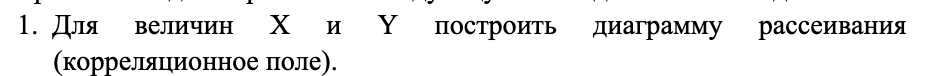

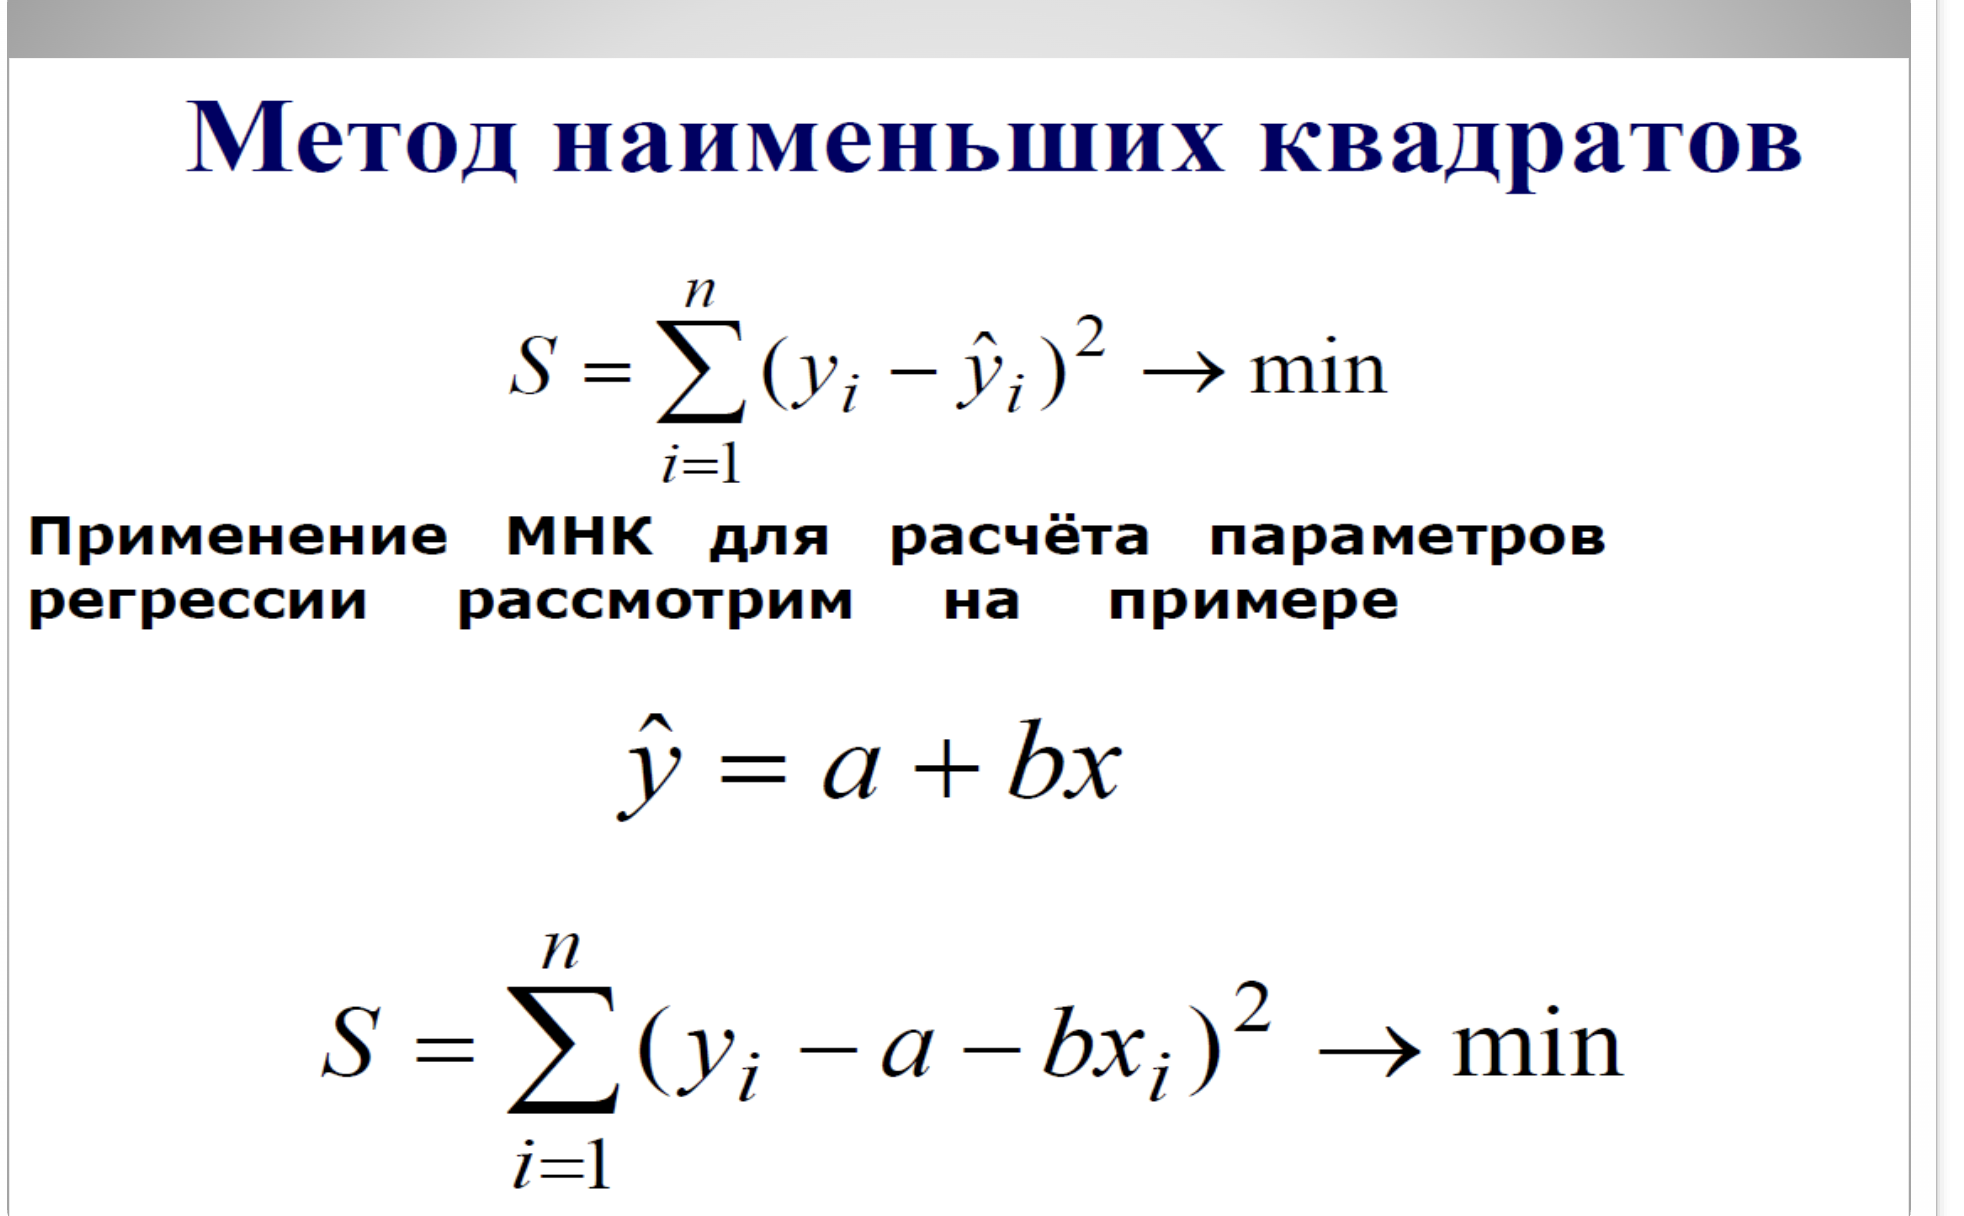

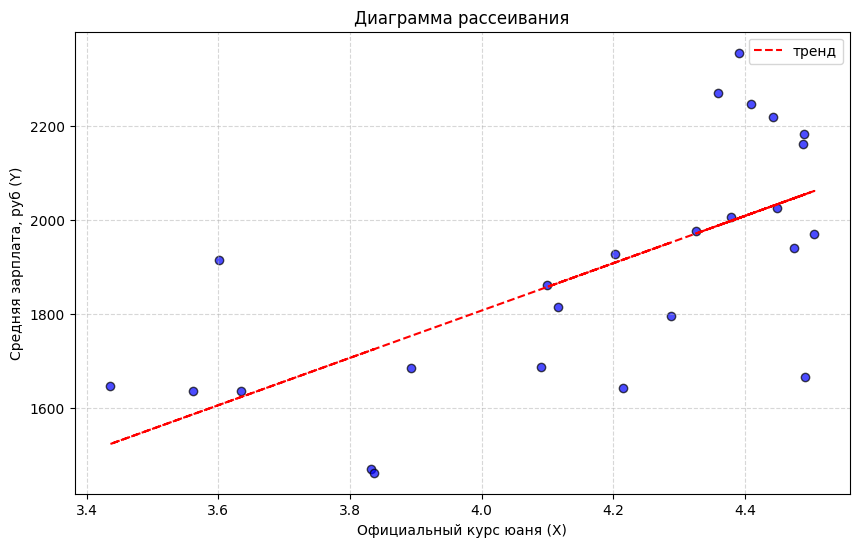

In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='blue', alpha=0.7, edgecolors='black')
plt.title('Диаграмма рассеивания')
plt.xlabel('Официальный курс юаня (X)')
plt.ylabel('Средняя зарплата, руб (Y)')
plt.grid(True, linestyle='--', alpha=0.5)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "r--", label='тренд')
plt.legend()

plt.show()

# 2
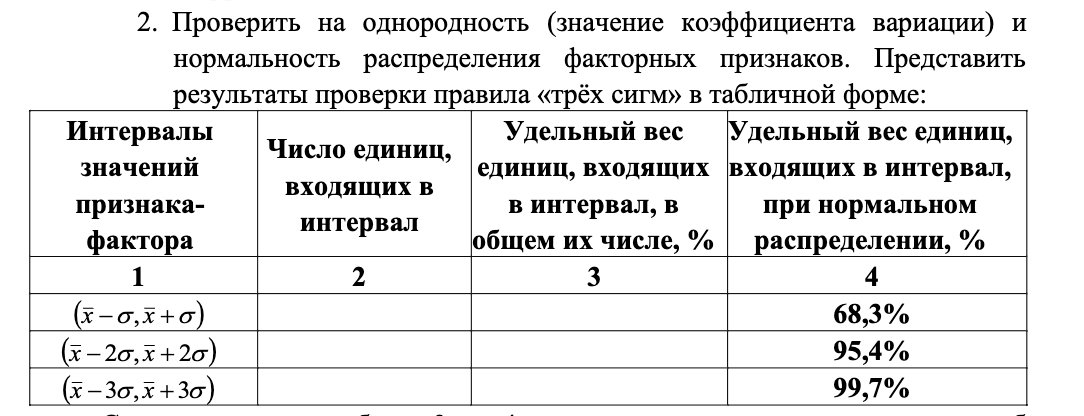

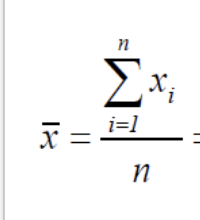

![коэффициент вариации.png](<attachment:коэффициент вариации.png>)

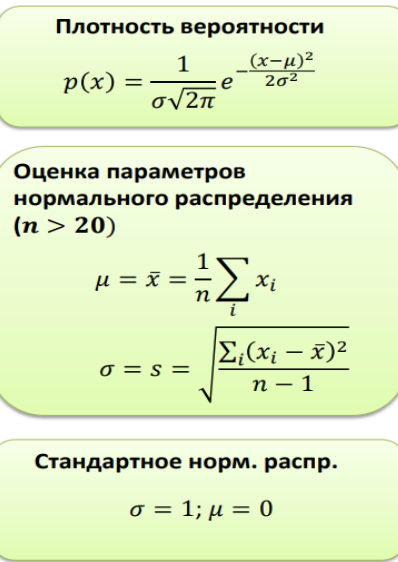
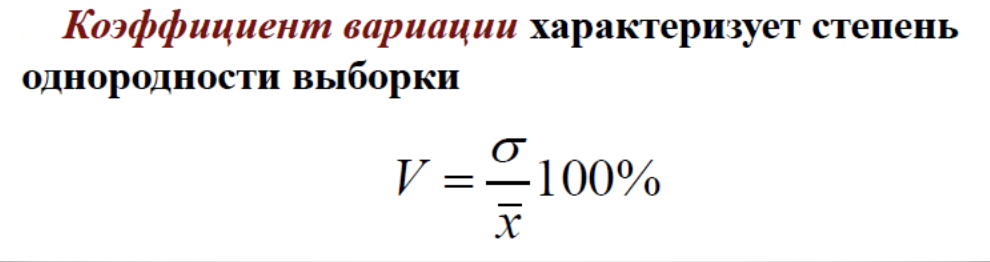

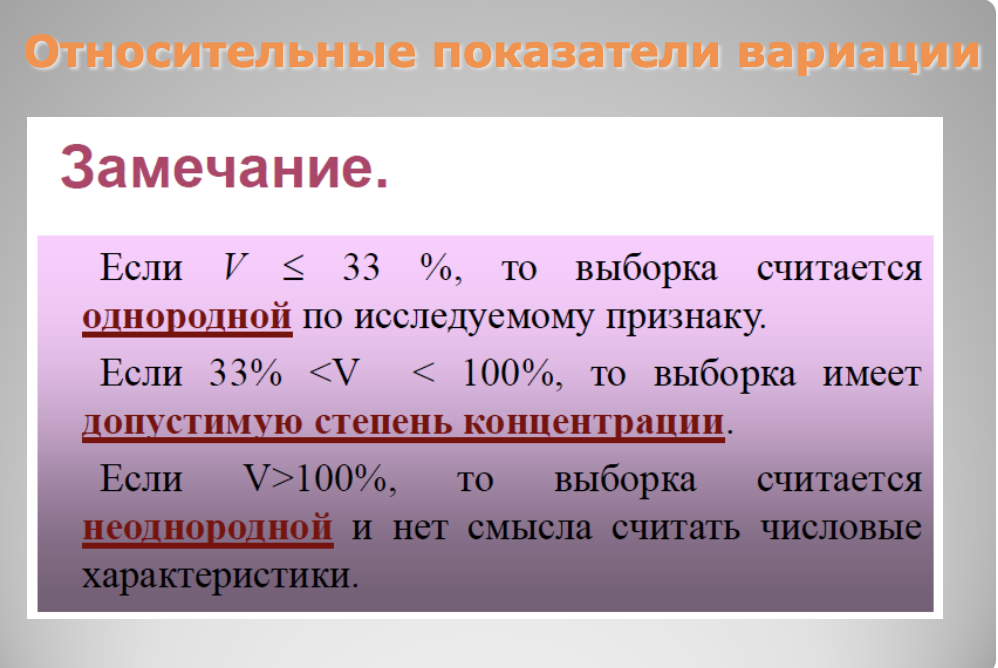

In [5]:
mean_x = x.mean() # среднее
std_x = x.std(ddof=1) # отклонение

# 1. Проверка на однородность
cv_x = (std_x / mean_x) * 100
print(f"Среднее X: {mean_x:.3f}")
print(f"Стандартное отклонение X (sigma): {std_x:.3f}")
print(f"Коэффициент вариации V: {cv_x:.2f}%")
if cv_x < 33:
    print("Вывод: V < 33%, совокупность однородна.\n")
else:
    print("Вывод: V > 33%, совокупность неоднородна.\n")

# считаем количество элементов, попадающих в интервалы
count_1s = ((x >= mean_x - std_x) & (x <= mean_x + std_x)).sum()
count_2s = ((x >= mean_x - 2*std_x) & (x <= mean_x + 2*std_x)).sum()
count_3s = ((x >= mean_x - 3*std_x) & (x <= mean_x + 3*std_x)).sum()

# таблица
sigma_table = pd.DataFrame({
    'Интервалы значений признака-фактора': [
        f"({mean_x - std_x:.3f} ; {mean_x + std_x:.3f})",
        f"({mean_x - 2*std_x:.3f} ; {mean_x + 2*std_x:.3f})",
        f"({mean_x - 3*std_x:.3f} ; {mean_x + 3*std_x:.3f})"
    ],
    'Число единиц, входящих в интервал': [count_1s, count_2s, count_3s],
    'Удельный вес единиц, входящих в интервал, в общем их числе, %': [
        round(count_1s / n * 100, 1),
        round(count_2s / n * 100, 1),
        round(count_3s / n * 100, 1)
    ],
    'Удельный вес единиц, входящих в интервал, при нормальном распределении, %': ['68,3%', '95,4%', '99,7%']
})

print("Таблица проверки правила «трёх сигм»:")
display(sigma_table)

Среднее X: 4.160
Стандартное отклонение X (sigma): 0.337
Коэффициент вариации V: 8.10%
Вывод: V < 33%, совокупность однородна.

Таблица проверки правила «трёх сигм»:


,Интервалы значений признака-фактора,"Число единиц, входящих в интервал","Удельный вес единиц, входящих в интервал, в общем их числе, %","Удельный вес единиц, входящих в интервал, при нормальном распределении, %"
0,(3.823 ; 4.497),20,80.0,"68,3%"
1,(3.486 ; 4.835),24,96.0,"95,4%"
2,(3.149 ; 5.172),25,100.0,"99,7%"


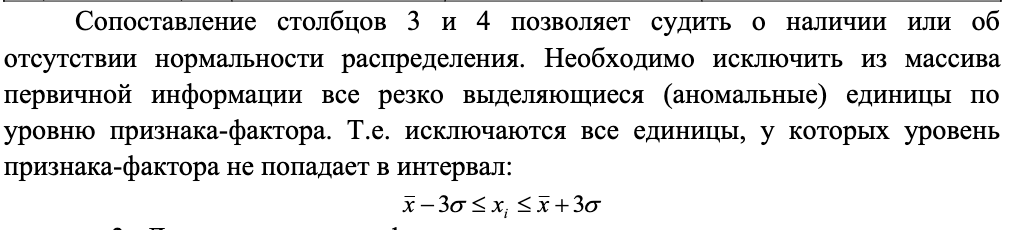

In [6]:
# исключение аномалий (фильтрация)
df_clean = df[(x >= mean_x - 3*std_x) & (x <= mean_x + 3*std_x)].copy()
anomalies_count = n - len(df_clean)
print(f"\nИсключено аномальных единиц: {anomalies_count}")

# получившиеся очищенные данные
x_clean = df_clean['X_Yuan']
y_clean = df_clean['Y_Wage']
n_clean = len(df_clean)


Исключено аномальных единиц: 0


# 3

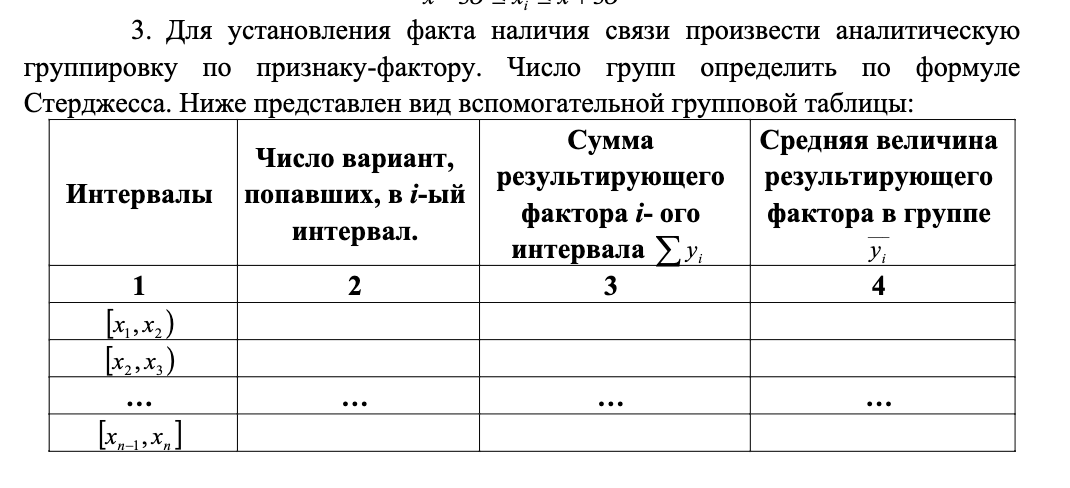

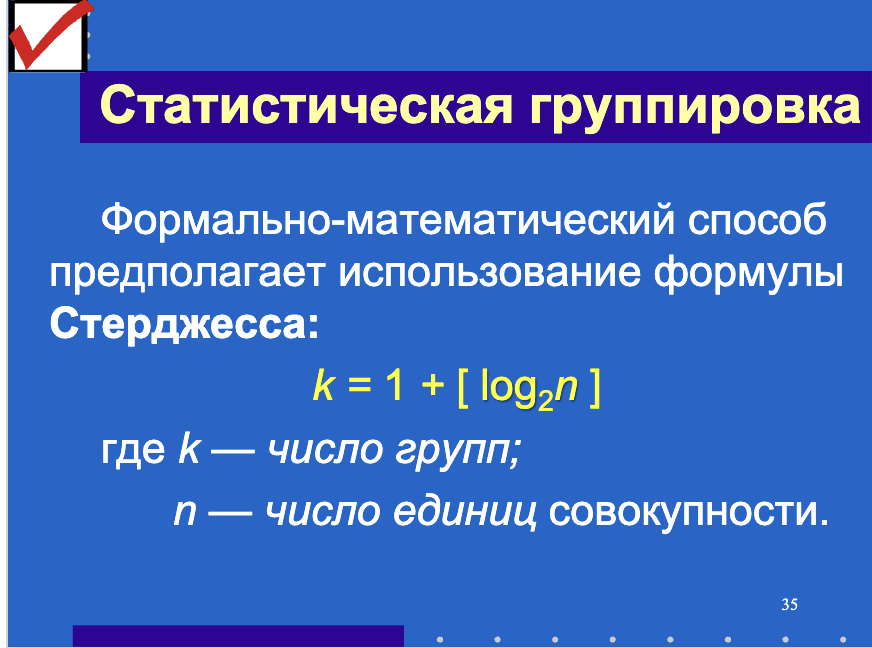

In [7]:
# Определяем число групп по Стерджессу
k = round(1 + 3.322 * math.log10(n_clean))
print(f"число групп по Стерджессу (k): {k}")

# интервалы. для этого pd.cut
df_clean['Group'] = pd.cut(x_clean, bins=k, right=False) # right=False значит [x1, x2)

# группируем и считаем
grouped = df_clean.groupby('Group', observed=False).agg(
    Число_вариант=('X_Yuan', 'count'),
    Сумма_Y=('Y_Wage', 'sum'),
    Средняя_Y=('Y_Wage', 'mean')
).reset_index()

# таблица
grouped.columns = [
    'Интервалы', 
    'Число вариант (попавших в интервал)', 
    'Сумма Y (в интервале)', 
    'Средняя величина Y']
grouped['Сумма Y (в интервале)'] = grouped['Сумма Y (в интервале)'].round(2)
grouped['Средняя величина Y'] = grouped['Средняя величина Y'].round(2)

display(grouped)

число групп по Стерджессу (k): 6


,Интервалы,Число вариант (попавших в интервал),Сумма Y (в интервале),Средняя величина Y
0,"[3.435, 3.614)",3,5200.2,1733.40
1,"[3.614, 3.792)",1,1637.0,1637.00
2,"[3.792, 3.97)",3,4619.8,1539.93
3,"[3.97, 4.149)",3,5363.1,1787.70
4,"[4.149, 4.327)",4,7342.6,1835.65
5,"[4.327, 4.507)",11,23042.5,2094.77


# 4

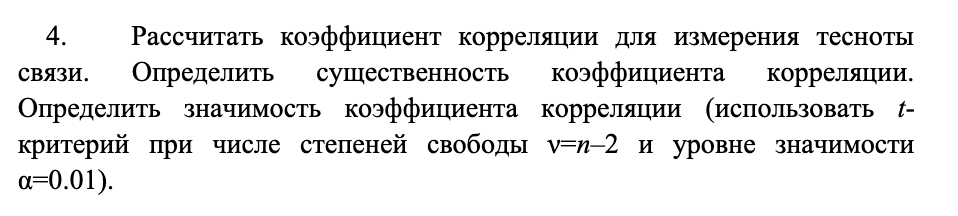

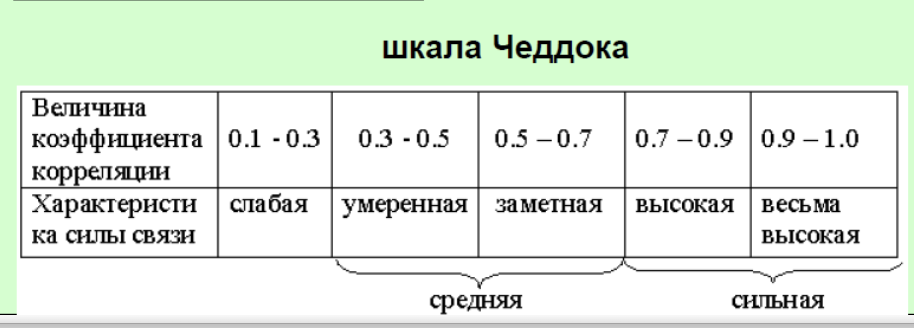

In [8]:
# коэффициент корреляции Пирсона (r)
r, p_value = stats.pearsonr(x_clean, y_clean)
print(f"Коэффициент корреляции (r): {r:.4f}")

# шкала Чеддока
if abs(r) < 0.3: tightness = "слабая"
elif abs(r) < 0.7: tightness = "средняя (умеренная)"
else: tightness = "сильная (тесная)"
print(f"Теснота связи: {tightness}")

Коэффициент корреляции (r): 0.6645
Теснота связи: средняя (умеренная)


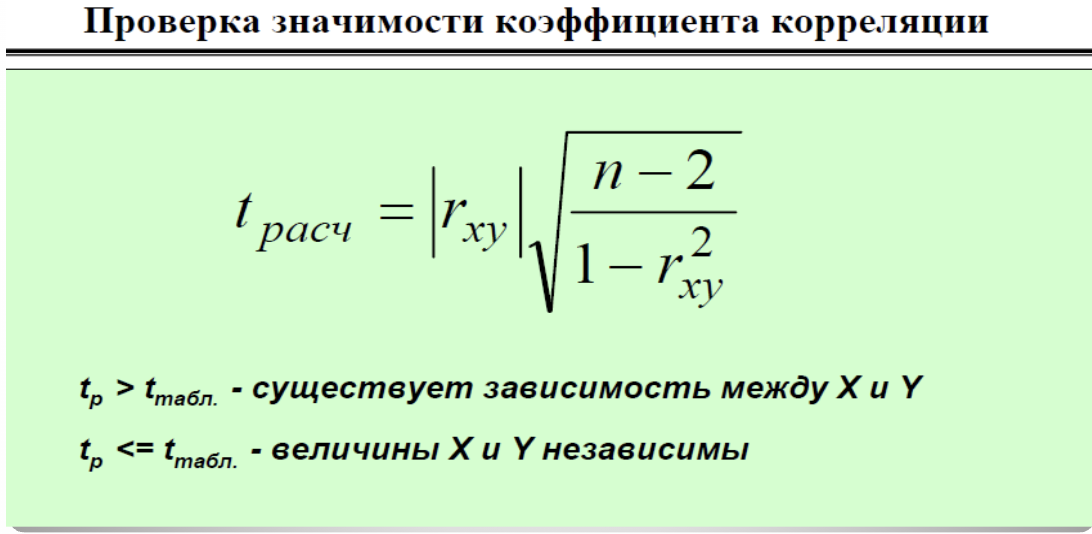

In [9]:
# t-критерий
# по условию задачи
alpha = 0.01
df_t = n_clean - 2

# наблюдаемое значение
t_obs = (abs(r) * math.sqrt(df_t)) / math.sqrt(1 - r**2)

# табличное значение
t_crit = stats.t.ppf(1 - alpha/2, df_t)

print(f"\число степеней свободы (v): {df_t}")
print(f"t-наблюдаемое: {t_obs:.4f}")
print(f"t-табличное: {t_crit:.4f}")

if t_obs > t_crit:
    print("\nt-набл > t-крит.")
    print("Между курсом юаня и средней зарплатой существует зависимость")
else:
    print("\nt-набл < t-крит.")
    print("Величины независимы")

\число степеней свободы (v): 23
t-наблюдаемое: 4.2640
t-табличное: 2.8073

t-набл > t-крит.
Между курсом юаня и средней зарплатой существует зависимость


# Лаб4

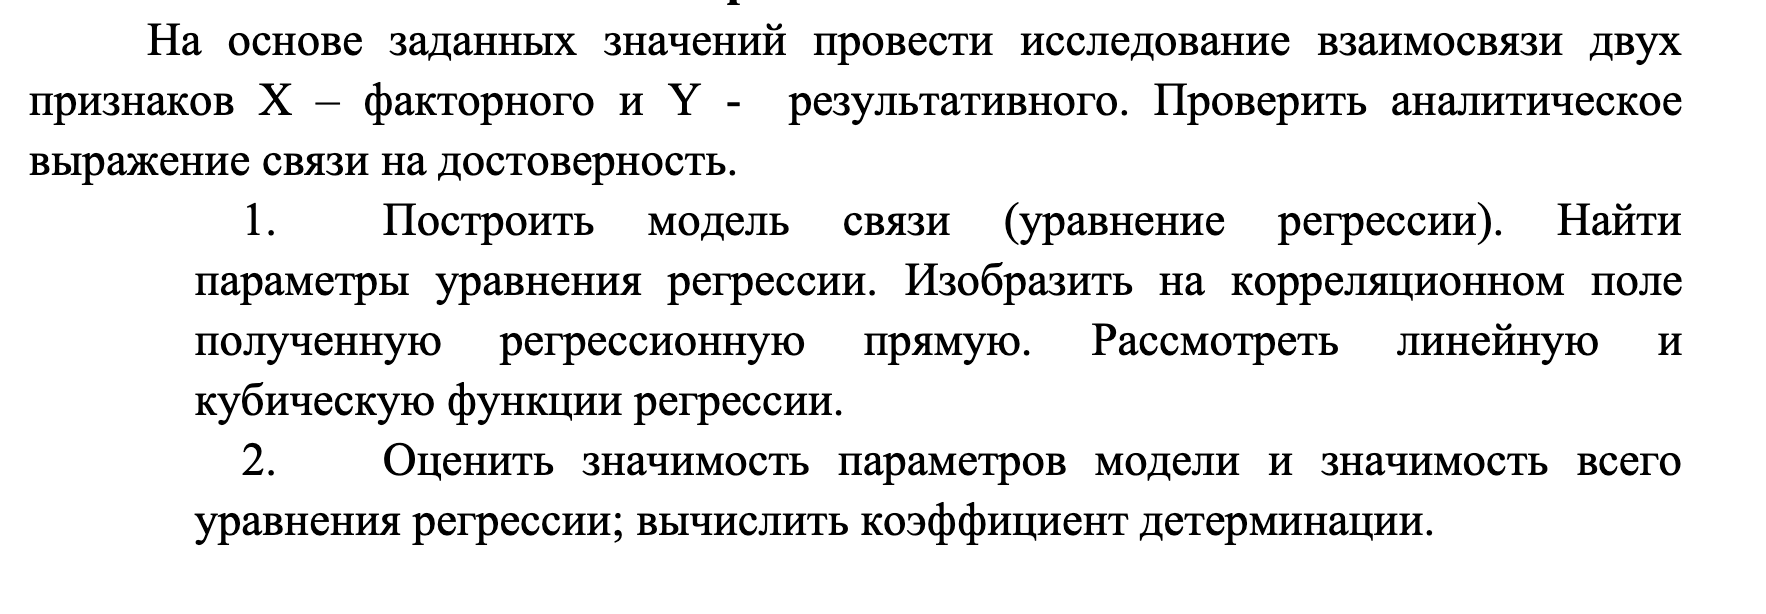

In [10]:
!pip install statsmodels

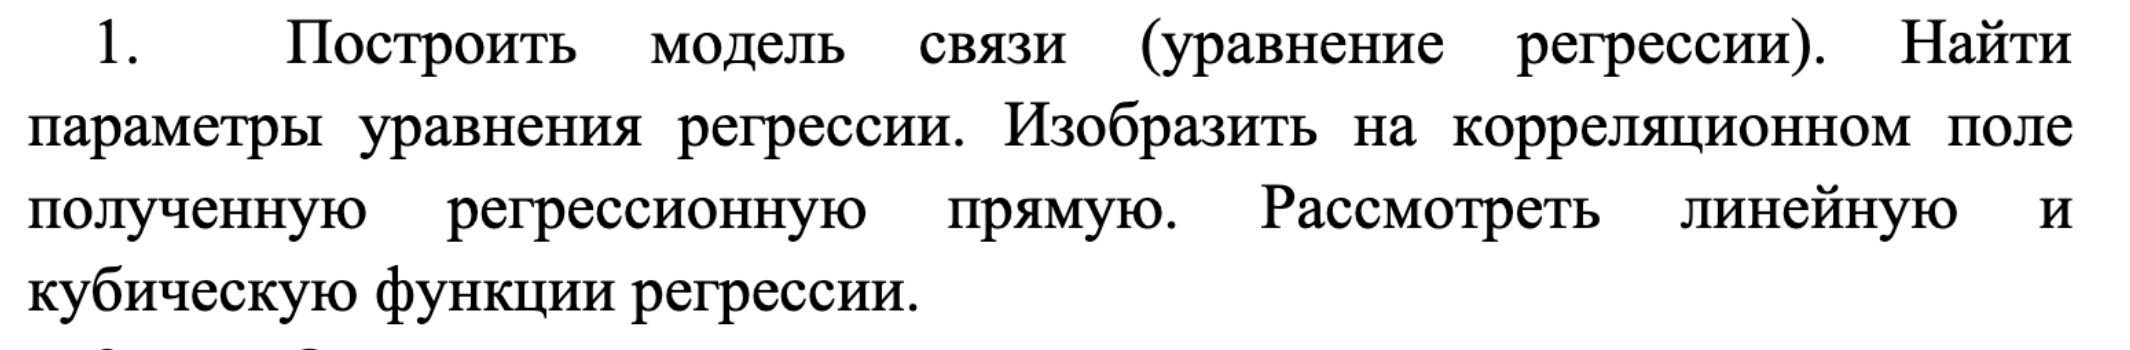

In [32]:
import statsmodels.api as sm
# линейная функция 

X_linear = sm.add_constant(x_clean) 
model_linear = sm.OLS(y_clean, X_linear).fit()

a = model_linear.params[0]
b = model_linear.params[1]

print("Линейная функция регрессии:")
print(f"Y = {a:.2f} + {b:.2f} * X")

Линейная функция регрессии:
Y = -202.15 + 502.43 * X


/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_23345/2172731306.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = model_linear.params[0]
/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_23345/2172731306.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = model_linear.params[1]


In [33]:
# кубическая регресия
coeffs_cubic = np.polyfit(x_clean, y_clean, 3)
p_cubic = np.poly1d(coeffs_cubic)

print("уравнение кубической регрессии:")
print(f"Y = {p_cubic[0]:.4f} * x^3 + {p_cubic[1]:.4f} * x^2 + {p_cubic[2]:.4f} * x + {p_cubic[3]:.4f}")

X_cubic = np.column_stack((x_clean, x_clean**2, x_clean**3))
X_cubic = sm.add_constant(X_cubic)
model_cubic = sm.OLS(y_clean, X_cubic).fit()

уравнение кубической регрессии:
Y = 128404.7897 * x^3 + -93719.2523 * x^2 + 22894.2599 * x + -1845.8050


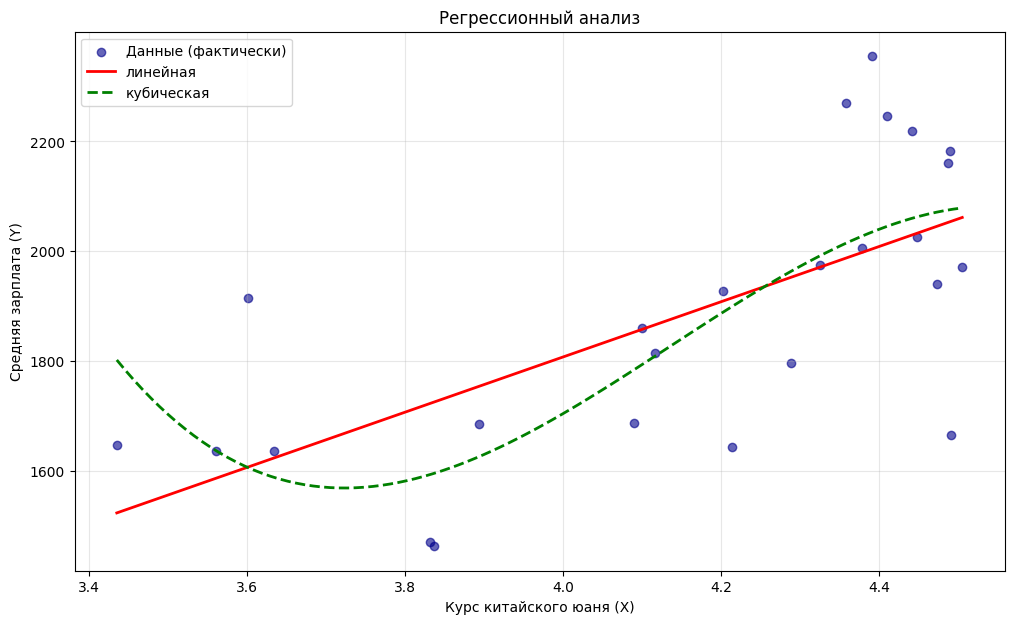

In [17]:
# изображаем на корреляционном поле полученную регрессию
plt.figure(figsize=(12, 7))

# корреляционное поле
plt.scatter(x_clean, y_clean, color='darkblue', label='Данные (фактически)', alpha=0.6)

# Создаем плавную линию для графиков
x_range = np.linspace(x_clean.min(), x_clean.max(), 100)

# линейная
plt.plot(x_range, a + b*x_range, 'r-', linewidth=2, label=f'линейная')

# кубическая 
plt.plot(x_range, p_cubic(x_range), 'g--', linewidth=2, label=f'кубическая')

plt.title('Регрессионный анализ')
plt.xlabel('Курс китайского юаня (X)')
plt.ylabel('Средняя зарплата (Y)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

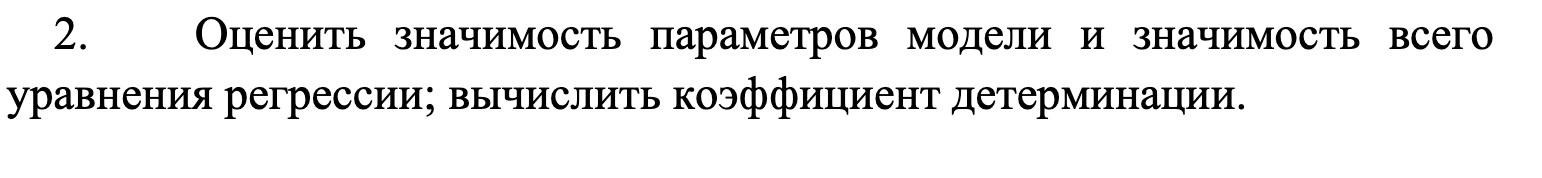

# Значимость для линейной

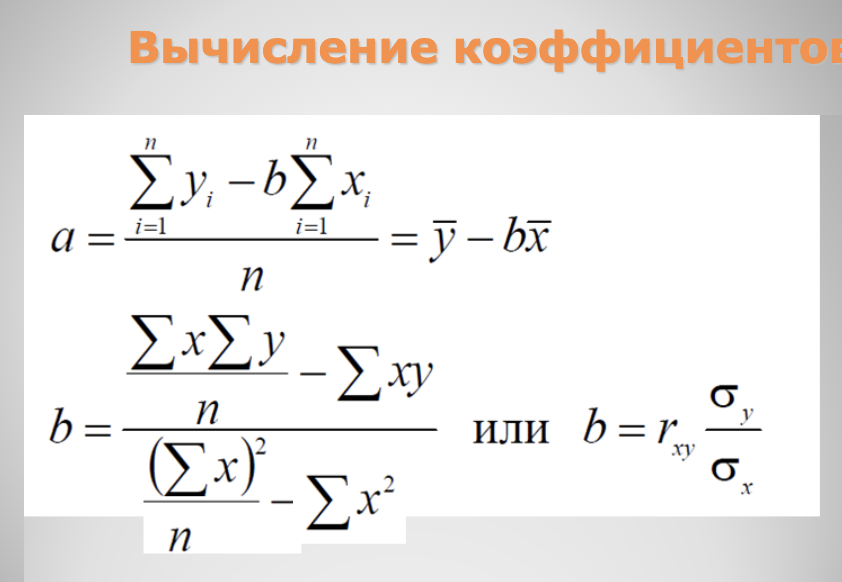

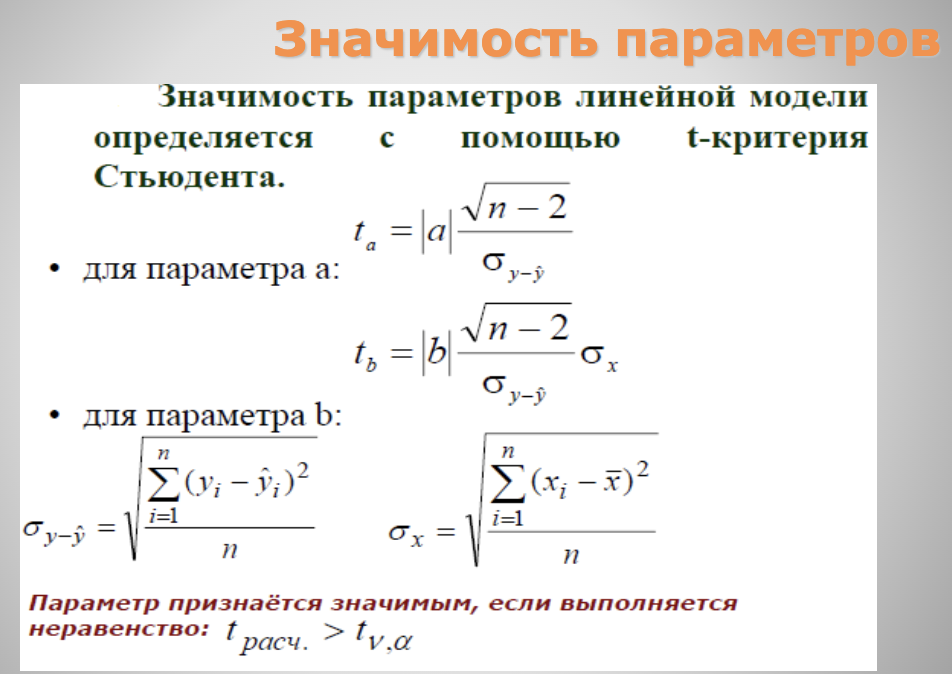

$\nu = n - m$  -- чилсо степеней свободы, где $m$ -- число оцениваемых параметров (для лин регрессии $m = 2$)

$\alpha = 0.05$

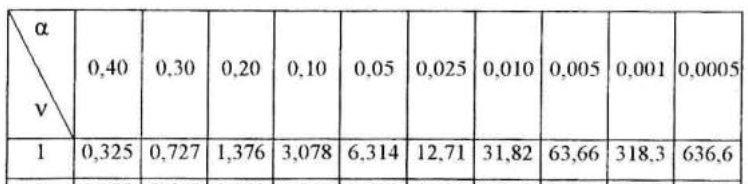

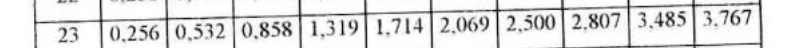

таким образом $t_{табл} = 1.714$ 

In [27]:
#  t_расчетные для t-статистики для параметров a и b
t_calc_a = abs(model_linear.tvalues[0])
t_calc_b = abs(model_linear.tvalues[1])

# табличное
t_table = 1.714 

print("ЗНАЧИМОСТЬ")
print(f"t_расч для 'a': {t_calc_a:.4f}")
print(f"t_расч для 'b': {t_calc_b:.4f}")
print(f"t_табл (при v=23, alpha=0.01): {t_table}")

if t_calc_a > t_table:
    print("Вывод по 'a': t_расч > t_табл. Параметр 'a' ЗНАЧИМ.")
else:
    print("Вывод по 'a': t_расч < t_табл. Параметр 'a' НЕ ЗНАЧИМ.")

if t_calc_b > t_table:
    print("Вывод по 'b': t_расч > t_табл. Параметр 'b' ЗНАЧИМ.")
else:
    print("Вывод по 'b': t_расч < t_табл. Параметр 'b' НЕ ЗНАЧИМ.")

ЗНАЧИМОСТЬ
t_расч для 'a': 0.4111
t_расч для 'b': 4.2640
t_табл (при v=23, alpha=0.01): 1.714
Вывод по 'a': t_расч < t_табл. Параметр 'a' НЕ ЗНАЧИМ.
Вывод по 'b': t_расч > t_табл. Параметр 'b' ЗНАЧИМ.


/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_23345/3246854583.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  t_calc_a = abs(model_linear.tvalues[0])
/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_23345/3246854583.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  t_calc_b = abs(model_linear.tvalues[1])


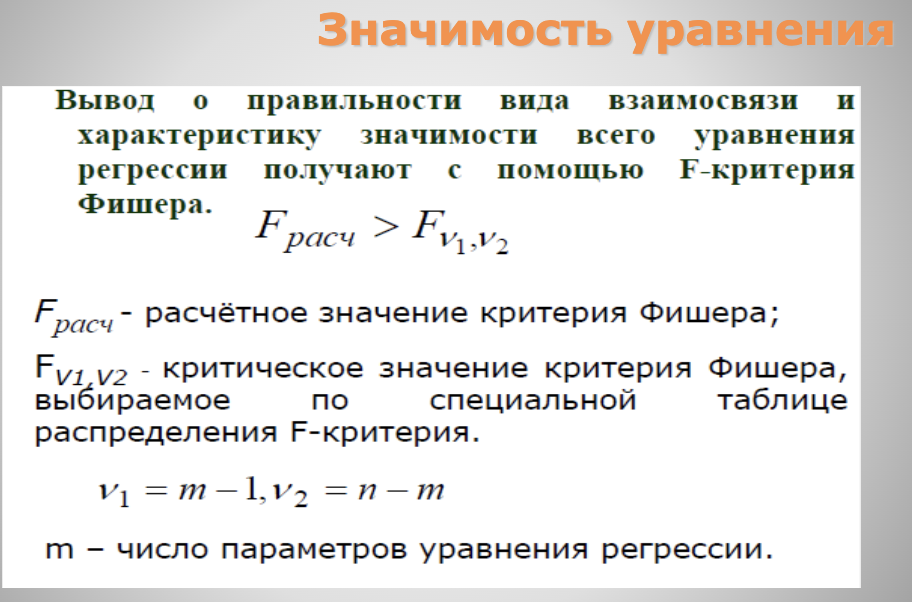

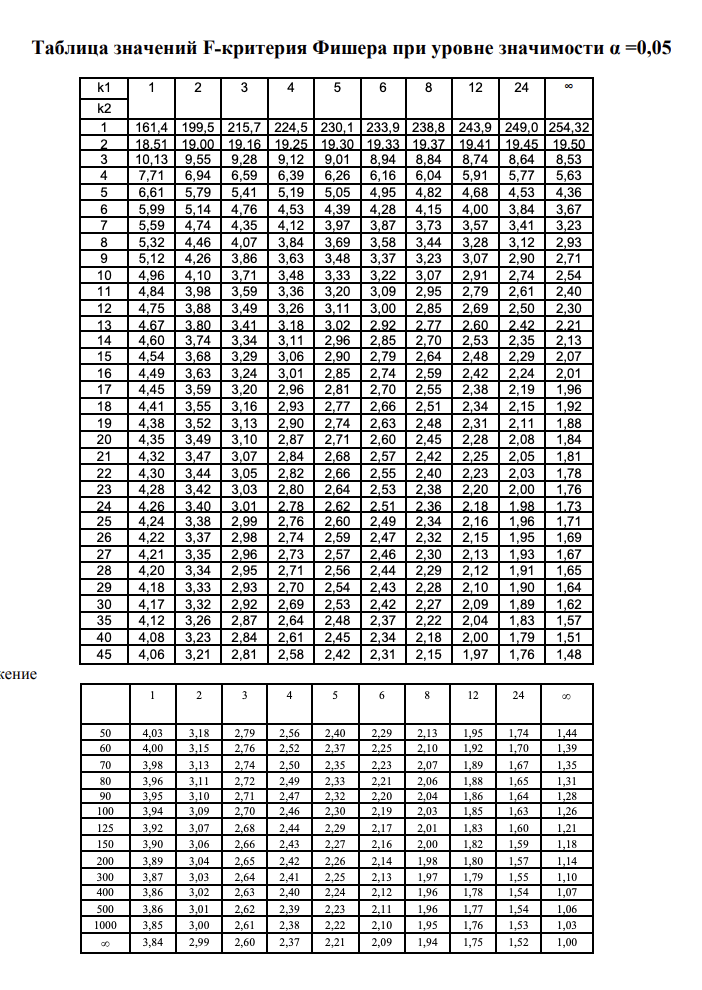
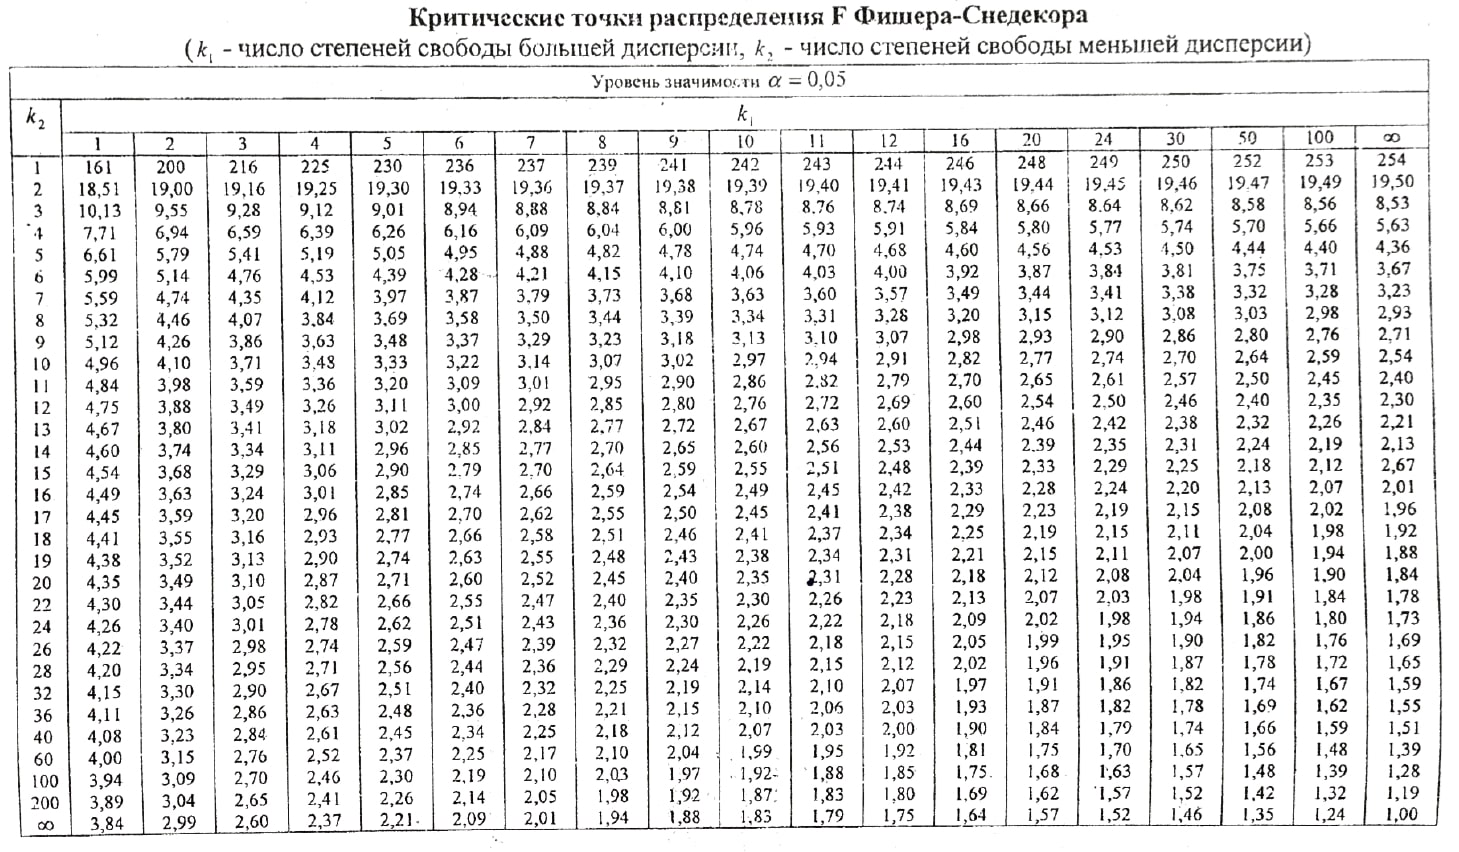

$n = 25$

$m = 2$ (два параметра -- $a$ и $b$)

$\nu_{1} = 2 - 1 = 1$

$\nu_{2} = 25 - 2 = 23$

таким образом табличное значение

$F_{\nu_1, \nu_2} = $ (при  $\alpha = 0.05$) $= 4.28$

In [25]:
# F_расч
F_calc = model_linear.fvalue

# F_табл
F_table = 4.28

print("\nЗНАЧИМОСТЬ УРАВНЕНИЯ")
print(f"F_расч: {F_calc:.4f}")
print(f"F_табл (при v1=1, v2=23, alpha=0.05): {F_table}")

if F_calc > F_table:
    print("Вывод: F_расч > F_табл. Уравнение регрессии ЗНАЧИМО.")
else:
    print("Вывод: F_расч < F_табл. Уравнение регрессии НЕ ЗНАЧИМО.")


ЗНАЧИМОСТЬ УРАВНЕНИЯ
F_расч: 18.1816
F_табл (при v1=1, v2=23, alpha=0.05): 4.28
Вывод: F_расч > F_табл. Уравнение регрессии ЗНАЧИМО.


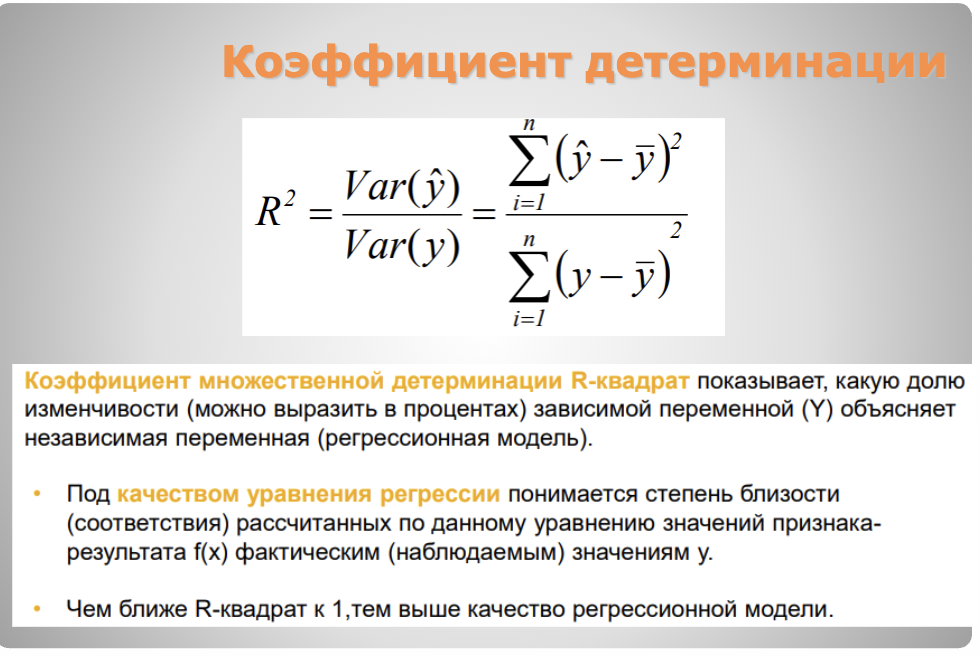

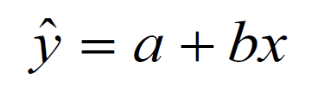

In [ ]:
R_squared = model_linear.rsquared

print("\nКОЭФФИЦИЕНТ ДЕТЕРМИНАЦИИ")
print(f"R^2 = {R_squared:.4f}")


--- КОЭФФИЦИЕНТ ДЕТЕРМИНАЦИИ ---
R^2 = 0.4415


# Значимость для кубической

$\nu = n - m = 25 - 4 = 21$

$\alpha = 0.05$

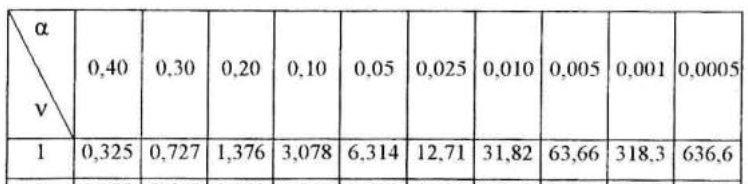

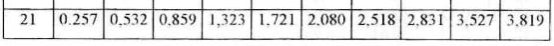

$t_{табл} = 1.721$

In [28]:
t_calc_cubic = abs(model_cubic.tvalues) 

t_table_cubic = 1.721

print("--- ЗНАЧИМОСТЬ (t-критерий) ---")
print(f"t_табл (при v=21, alpha=0.01): {t_table_cubic}")
print("-" * 40)

param_names = ['a (X^0)', 'b (X^1)', 'c (X^2)', 'd (X^3)']
for i in range(4):
    t_val = t_calc_cubic[i]
    if t_val > t_table_cubic:
        print(f"Параметр {param_names[i]}: t_расч = {t_val:.4f} > t_табл. ЗНАЧИМ.")
    else:
        print(f"Параметр {param_names[i]}: t_расч = {t_val:.4f} < t_табл. НЕ ЗНАЧИМ.")

--- ЗНАЧИМОСТЬ (t-критерий) ---
t_табл (при v=21, alpha=0.01): 1.721
----------------------------------------
Параметр a (X^0): t_расч = 1.3691 < t_табл. НЕ ЗНАЧИМ.
Параметр b (X^1): t_расч = 1.3255 < t_табл. НЕ ЗНАЧИМ.
Параметр c (X^2): t_расч = 1.2934 < t_табл. НЕ ЗНАЧИМ.
Параметр d (X^3): t_расч = 1.2541 < t_табл. НЕ ЗНАЧИМ.


/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_23345/3237523488.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  t_val = t_calc_cubic[i]


## Значимость уравнения
 
$\nu_1 = m - 1 = 4 - 1 = 3$

$\nu_2 = n - m = 25 - 4 = 21$ 

$\alpha = 0.05$

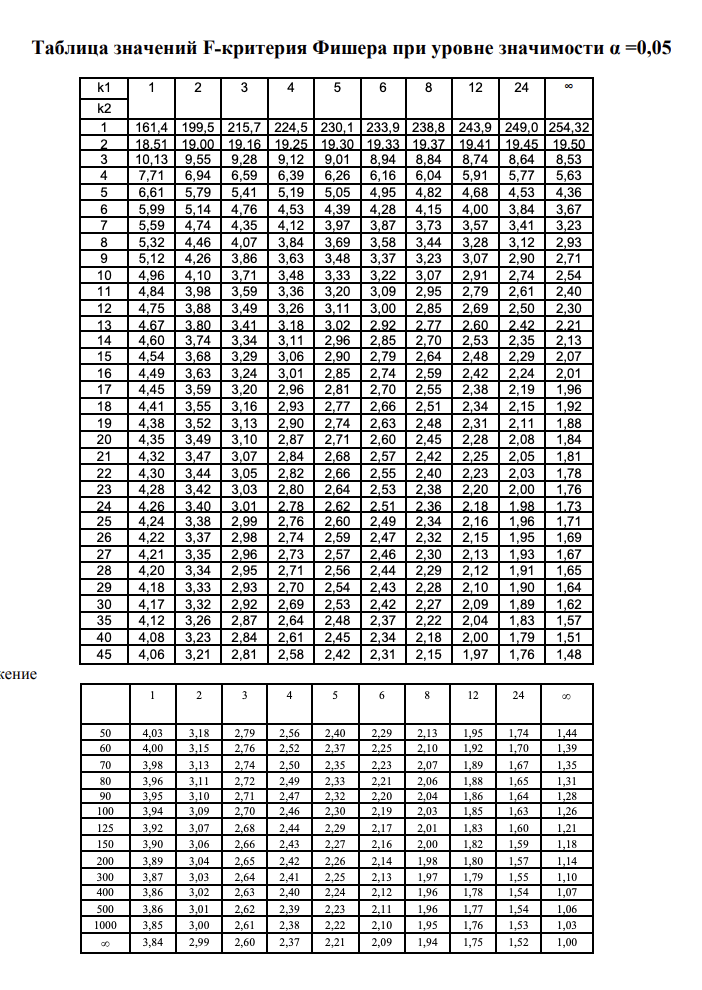

итого $F_{табл} = 3,07$

In [29]:
F_calc_cubic = model_cubic.fvalue # F_расч

F_table_cubic = 3.07

print("\nЗНАЧИМОСТЬ УРАВНЕНИЯ")
print(f"F_расч: {F_calc_cubic:.4f}")
print(f"F_табл (при v1=3, v2=21, alpha=0.05): {F_table_cubic}")

if F_calc_cubic > F_table_cubic:
    print("Вывод: F_расч > F_табл. уравнение регрессии ЗНАЧИМО.")
else:
    print("Вывод: F_расч < F_табл. уравнение регрессии НЕ ЗНАЧИМО.")


ЗНАЧИМОСТЬ УРАВНЕНИЯ
F_расч: 8.1920
F_табл (при v1=3, v2=21, alpha=0.05): 3.07
Вывод: F_расч > F_табл. уравнение регрессии ЗНАЧИМО.


## Коэффициент детерминации

In [30]:
R_squared_cubic = model_cubic.rsquared

print("\nКОЭФФИЦИЕНТ ДЕТЕРМИНАЦИИ")
print(f"R^2 = {R_squared_cubic:.4f}")


КОЭФФИЦИЕНТ ДЕТЕРМИНАЦИИ
R^2 = 0.5392


> объяснеяет 53.92% изменчивости зарплат

о формулах

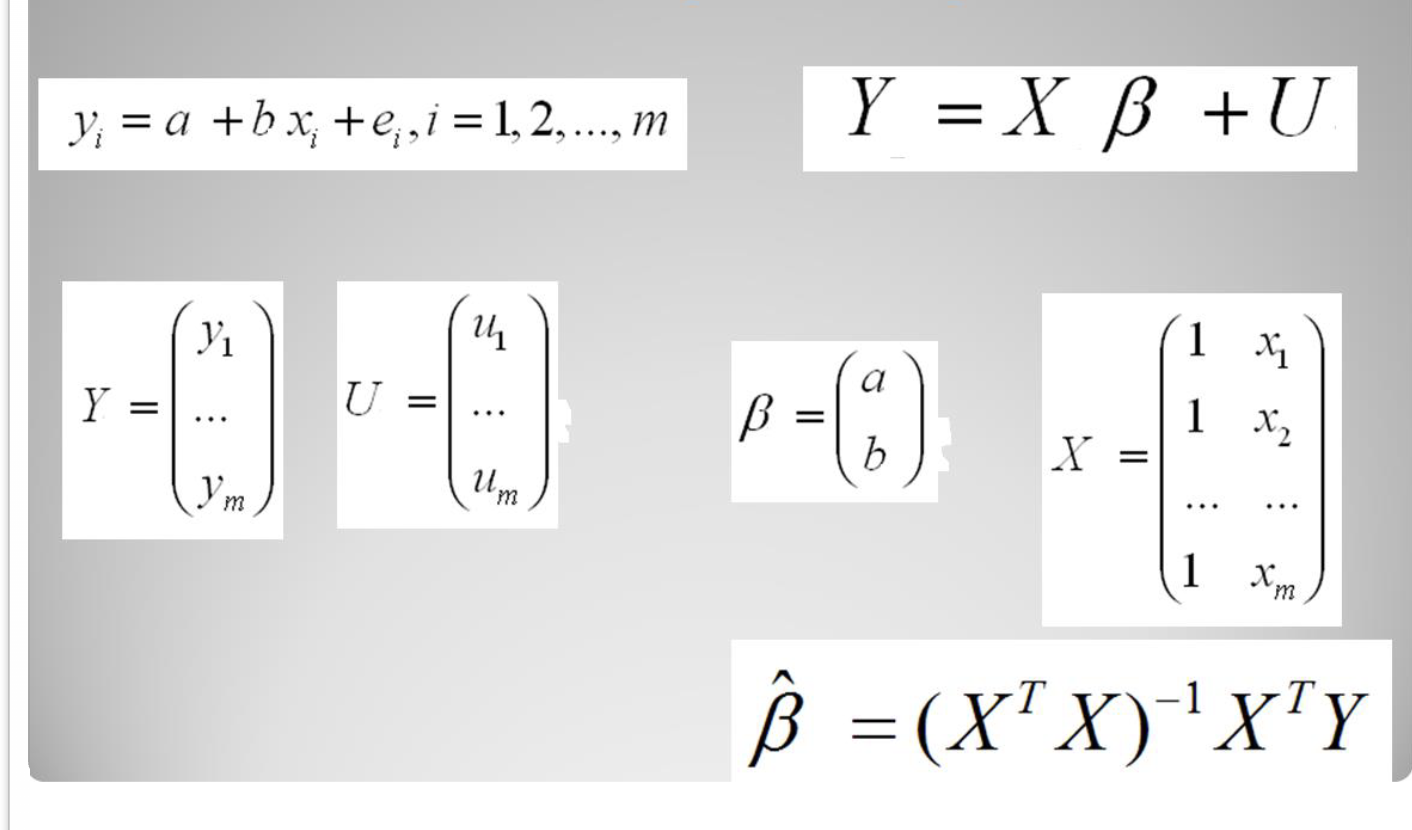